# Intro

This project tackles a binary classification challenge using the "Adult"[0] dataset from the UCI Machine Learning Repository. The aim is to build a predictive model that can determine whether an individual's income surpasses $50,000 annually. This will be achieved by analyzing various census features available within the dataset.

This can help discern how socioeconomic and demographic factors influence the economic status.

Link to the dataset: https://archive.ics.uci.edu/dataset/2/adult

[0]: B. Becker and R. Kohavi. "Adult," UCI Machine Learning Repository, 1996. [Online]. Available: https://doi.org/10.24432/C5XW20.

## Description

The data set contains 48842 entries. 32561 will be considered as training data while the rest will be used for validation.

The features are descibred as below

**age**: continuous.

**workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.

**fnlwgt** (Final weight: the number of people the census believes to be part of the entry): continuous.

**education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.

**education-num** (same as above, but numerical): continuous.

**marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.

**occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

**relationship** (the status of the person in the family): Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.

**race**: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.

**sex**: Female, Male.

**capital-gain**: continuous.

**capital-loss**: continuous.

**hours-per-week**: continuous.

**native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

The target variable is labelled as "income" and the values are <=50K and >50K.

The data extraction was done by Barry Becker from the 1994 Census database

# Setting up

To begin, we'll import key Python modules: pandas for data handling, NumPy for numerical tasks, and seabord/matplotlib for helping with plotting.

In [2]:
import math
import pickle
import gzip
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
%matplotlib inline

sns.set
# importing all the required libraries
%matplotlib inline

Now, we'll load the training and testing datasets, preparing them for model training. However, the CSV files exhibit some inconsistencies in formatting.
We adjust the function parameters and do a preprocessing to have an uniform set of data.

Note that the CSV don't includes the column names, we are specifying them manually.

In [115]:
# Column names are not part of the data files

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

def load_train_data():
    df = pd.read_csv("adult/adult.data", header=None, index_col=False, names=column_names, skipinitialspace=True)
    return df

def load_test_data():
    df = pd.read_csv("adult/adult.test", skiprows=1, header=None, index_col=False, names=column_names, skipinitialspace=True)
    df['income'] = df.income.apply(lambda x: x[:-1]) # removing a dot at the end of each row
    return df

train_data = load_train_data()
test_data = load_test_data()

Checking the dataset's dimensions and a few representative entries for initial understanding.

In [116]:
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Data cleaning and processing


## Missing values

Although initial cleaning steps were performed, the current dataset requires further preprocessing to enable meaningful analysis.

Our next step involves dealing with incomplete entries. According to the dataset's specifications, the "workclass," "occupation," and "native-country" columns should not contain missing values. Therefore, we will remove any rows where these features are absent.

This action is crucial because a missing value in these particular columns signifies a potentially malformed or incomplete data point that could negatively impact subsequent analysis and modeling.

In [76]:
initial_train_len = len(train_data)
initial_test_len = len(test_data)

In [117]:
def remove_missing_value(data):
  return data.query('workclass != "?" and occupation != "?" and `native-country` != "?"')

train_data_v2 = remove_missing_value(train_data)
test_data = remove_missing_value(test_data)

train_removed_rows_count = initial_train_len - len(train_data_v2)
test_removed_rows_count = initial_test_len - len(test_data)
print(f'Removed {train_removed_rows_count} row(s) ({100 * train_removed_rows_count / initial_train_len:.2f}%) from train data')
print(f'Removed {test_removed_rows_count} row(s) ({100 * test_removed_rows_count / initial_test_len:.2f}%) from test data')

Removed 2399 row(s) (7.37%) from train data
Removed 1221 row(s) (7.50%) from test data


As we can see, the removed rows do not impact significantly the available training data and validation dta.

## Initial Feature Reduction for Simplified Analysis

To streamline our analysis and focus on the most pertinent factors influencing income, we will remove several features.

*capital-loss* and *capital-gain* are excluded as they represent income from investments, distinct from salary

*education* is redundant given the presence of *education-num*, a numerical representation.

*fnlwgt*, representing population weights, is deemed irrelevant to individual income prediction.

*relationship* is considered to have a minimal direct impact on income variation.

In [120]:
# We are combining the dataframes for easier feature manipulation
combined_df = pd.concat([train_data_v2, test_data], ignore_index=True)
train_size = len(train_data_v2)

combined_df = combined_df.drop(columns=['capital-loss', 'capital-gain', 'education', 'fnlwgt', 'relationship'])

combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education-num   45222 non-null  int64 
 3   marital-status  45222 non-null  object
 4   occupation      45222 non-null  object
 5   race            45222 non-null  object
 6   sex             45222 non-null  object
 7   hours-per-week  45222 non-null  int64 
 8   native-country  45222 non-null  object
 9   income          45222 non-null  object
dtypes: int64(3), object(7)
memory usage: 3.5+ MB



## Categorical features

Several features are currently represented as categorical strings, which are unsuitable for many analytical techniques, especially those involving correlation studies. To address this, we'll employ dummy variable encoding. This technique transforms each categorical feature into a set of binary (0 or 1) features. Each new binary feature represents a unique value from the original categorical feature, indicating its presence or absence in a given observation.

In [121]:
categorical = ["workclass", "marital-status", "occupation", "race", "sex" , "native-country"]

combined_df_v2 = pd.get_dummies(combined_df, columns=categorical, drop_first=True)

combined_df_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 74 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   age                                        45222 non-null  int64 
 1   education-num                              45222 non-null  int64 
 2   hours-per-week                             45222 non-null  int64 
 3   income                                     45222 non-null  object
 4   workclass_Local-gov                        45222 non-null  bool  
 5   workclass_Private                          45222 non-null  bool  
 6   workclass_Self-emp-inc                     45222 non-null  bool  
 7   workclass_Self-emp-not-inc                 45222 non-null  bool  
 8   workclass_State-gov                        45222 non-null  bool  
 9   workclass_Without-pay                      45222 non-null  bool  
 10  marital-status_Married-AF-spouse  

# Analysis



In [181]:
training_data, testing_data = train_test_split(combined_df_v2, train_size=train_size, shuffle=False, random_state=None)

# put income at first position
training_data = training_data[['income'] + [c for c in training_data.columns if c != 'income']]
# convert income to binary
training_data['income'] = training_data.income.apply(lambda x: 1 if x == '>50K' else 0)

Let's check how income is related to education level.

<Axes: xlabel='income', ylabel='education'>

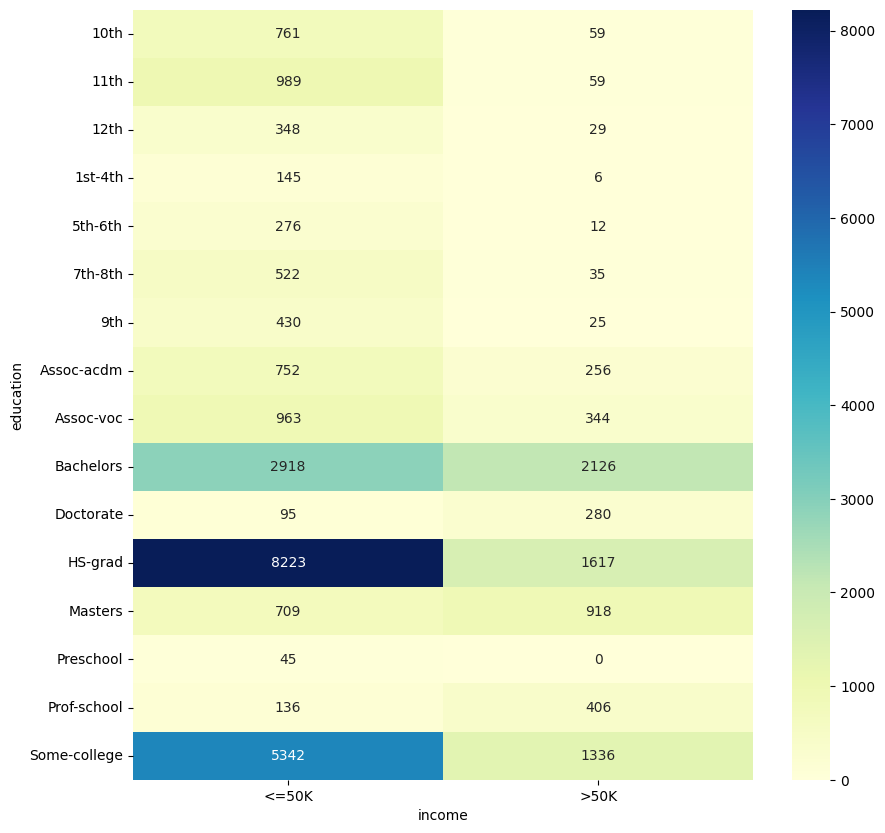

In [196]:
contingency_table = pd.crosstab(train_data_v2['education'], train_data_v2['income'])
plt.figure(figsize=(10, 10))
sns.heatmap(contingency_table, annot=True, cmap='YlGnBu', fmt='d')

We can can see that that Doctorate have a fair chance of exceeding an income of 50K, But while the ods invert for other category, it's easy to see that the chance increases with higher education.

<Axes: xlabel='age', ylabel='Count'>

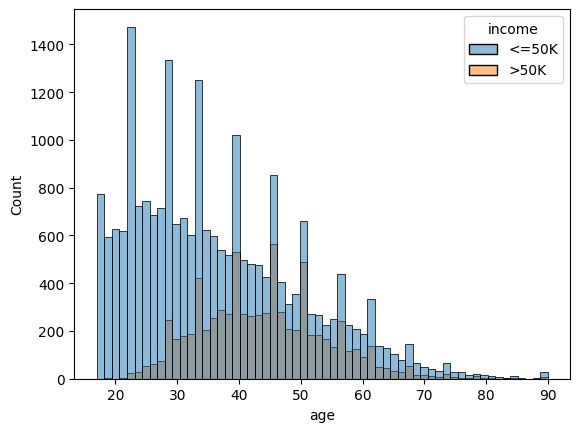

In [195]:
sns.histplot(train_data_v2, x='age', stat='count', hue="income")

The above plot explore the relation between age and income. We can see that it's more likely to have an income greater than 50k around and between 40 and 50. But the odd is still inferior for a given age.

# Modeling

Now, we'll get the data ready for model training by separating the "income" column, which is our target variable, from the remaining features.

We also split our train data from the above

In [165]:
from sklearn.model_selection import train_test_split

X = combined_df_v2.drop(columns=['income'])
y = combined_df_v2.income.apply(lambda x: 1 if x == '>50K' else 0)

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=train_size, shuffle=False, random_state=None)

In [203]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model):
  y_pred_proba = model.predict_proba(x_test)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
  # Calculate the Area Under the Curve (AUC)
  #    -  AUC provides a single number that summarizes the overall performance
  #       of the classifier.  A higher AUC indicates better performance.
  roc_auc = auc(fpr, tpr)
   # Plot the ROC Curve
  #   -  Use Seaborn and Matplotlib to create a visually appealing plot.
  plt.figure(figsize=(8, 6))
  sns.lineplot(x=fpr, y=tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], 'k--', label='Random guess')  # Diagonal line for random classifier
  plt.xlabel('False Positive Rate (FPR)')
  plt.ylabel('True Positive Rate (TPR)')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.xlim([0.0, 1.0])  # Set x-axis limits
  plt.ylim([0.0, 1.05]) # Set y-axis limits, slightly above 1.0
  plt.legend(loc='lower right')
  plt.grid(True)        # Add a grid for easier reading
  plt.show()

## Logistic Regresion

Our initial modeling approach will involve exploring the capabilities of logistic regression. This classification algorithm is well-suited for binary outcome prediction, and we aim to establish a baseline performance metric using this method. By examining the results of the logistic regression model, we can gain an initial understanding of the predictive power of our features on the income variable before investigating more complex models.

In [166]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(solver='liblinear').fit(x_train, y_train)

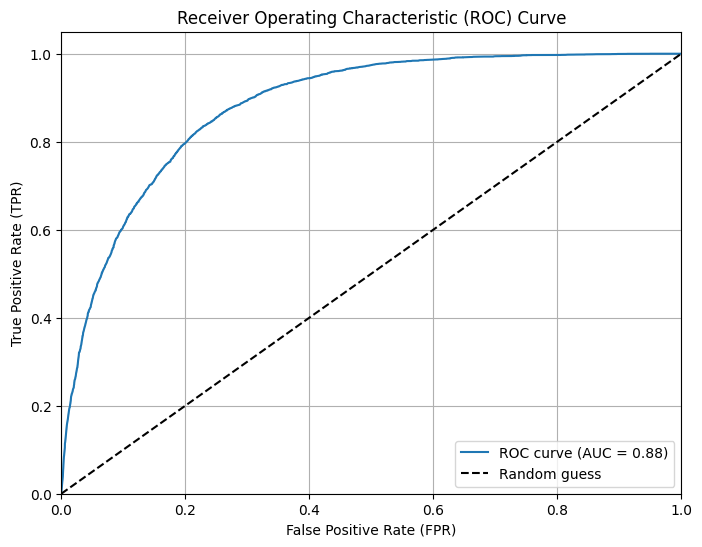

In [208]:
plot_roc(lr_model)

In [168]:
sorted([(x, y) for x,y in zip(lr_model.feature_names_in_, lr_model.coef_[0])], key=(lambda x: x[1]), reverse=True)


[('marital-status_Married-AF-spouse', np.float64(2.2472488637022887)),
 ('marital-status_Married-civ-spouse', np.float64(2.025739555591939)),
 ('occupation_Exec-managerial', np.float64(0.7907442054095237)),
 ('native-country_Italy', np.float64(0.6277488232282633)),
 ('occupation_Prof-specialty', np.float64(0.5842619576461552)),
 ('occupation_Tech-support', np.float64(0.5500532246754549)),
 ('occupation_Protective-serv', np.float64(0.49427553507050603)),
 ('native-country_France', np.float64(0.38267980311436967)),
 ('education-num', np.float64(0.2924391071329978)),
 ('native-country_Germany', np.float64(0.275445391145369)),
 ('race_Asian-Pac-Islander', np.float64(0.26838735653516205)),
 ('occupation_Sales', np.float64(0.24987749819695318)),
 ('native-country_Yugoslavia', np.float64(0.24438939503869353)),
 ('native-country_Ireland', np.float64(0.21482420061232618)),
 ('native-country_Canada', np.float64(0.20267378234050457)),
 ('sex_Male', np.float64(0.1998547859137563)),
 ('race_White',

## Random Forest ensemble

Following our logistic regression analysis, we will construct a Random Forest model. This ensemble learning technique is particularly effective for predictive tasks involving numerous features and complex relationships within the data. By leveraging the power of multiple decision trees, we anticipate that the Random Forest will offer improved predictive accuracy compared to the initial logistic regression model.

In [169]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=500, max_depth=3).fit(x_train, y_train)

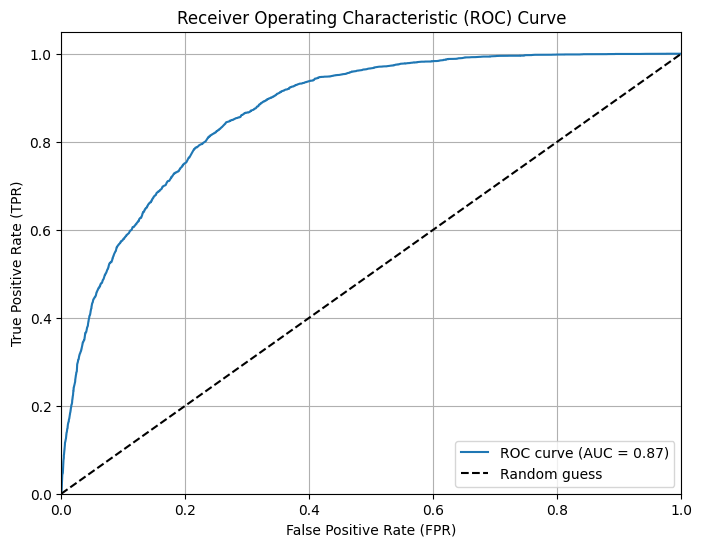

In [207]:
plot_roc(rf_model)

In [171]:
sorted([(x, y) for x,y in zip(rf_model.feature_names_in_, rf_model.feature_importances_)], key=(lambda x: x[1]), reverse=True)


[('marital-status_Married-civ-spouse', np.float64(0.22082980815078468)),
 ('education-num', np.float64(0.1536792353377768)),
 ('marital-status_Never-married', np.float64(0.14545896430293015)),
 ('age', np.float64(0.12030788216857795)),
 ('hours-per-week', np.float64(0.07638687269054369)),
 ('sex_Male', np.float64(0.07031463217500922)),
 ('occupation_Exec-managerial', np.float64(0.06564759966336732)),
 ('occupation_Prof-specialty', np.float64(0.03788909903680177)),
 ('occupation_Other-service', np.float64(0.03145642545022861)),
 ('workclass_Self-emp-inc', np.float64(0.01880969911171509)),
 ('workclass_Private', np.float64(0.011232714234275236)),
 ('occupation_Handlers-cleaners', np.float64(0.009289930509912066)),
 ('race_Black', np.float64(0.007261158874746957)),
 ('race_White', np.float64(0.005163583081152186)),
 ('occupation_Machine-op-inspct', np.float64(0.004661830997828432)),
 ('marital-status_Separated', np.float64(0.004566356909264213)),
 ('native-country_Mexico', np.float64(0.00

## Adaboost

Next, we will explore the AdaBoost algorithm, another powerful ensemble method. Unlike the base decision tree, which can easily overfit the training data, AdaBoost mitigates this by iteratively focusing on misclassified samples, assigning them higher weights in subsequent learning rounds. This approach contrasts with Random Forest, which primarily aims to reduce variance by promoting feature independence among its trees.

In [172]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adab_t_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100).fit(x_train, y_train)

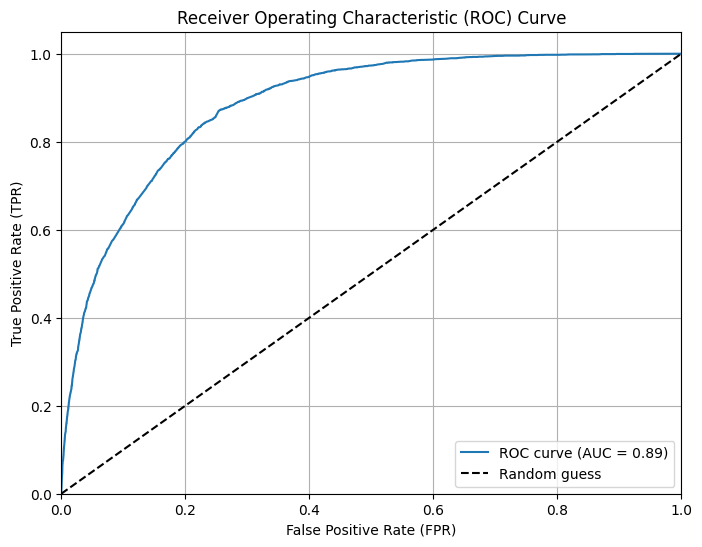

In [212]:
plot_roc(adab_t_model)

## GradientBoost

Our final modeling exploration will involve the HistGradientBoostingClassifier. This gradient boosting variant is particularly efficient and often outperforms the standard gradient boosting method when dealing with datasets containing more than 10,000 samples. Its optimized structure allows for faster training times and competitive predictive performance on larger datasets like ours.

In [174]:
from sklearn.ensemble import HistGradientBoostingClassifier

grad_t_model = HistGradientBoostingClassifier(max_depth=3, max_iter=100).fit(x_train, y_train)

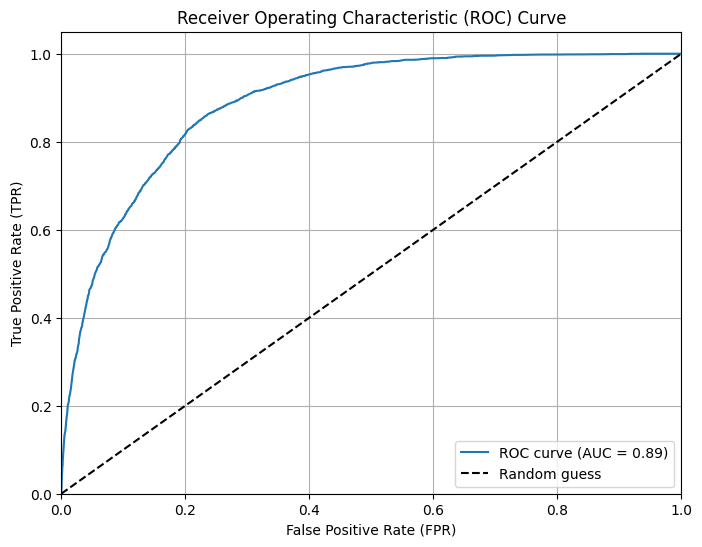

In [213]:
plot_roc(grad_t_model)

# Summary

We can see that all the models we use above perform admirably, with the algorithm being gradient boosting with an AUC = 0.89